This workbook goes over my final project for STA9794, Causal Inference & AB Testing.

I chose to do my project on Differences-In-Differences (DiD) and Synthetic Differences-In-Differences (SDiD).

I am using DiD/SDiD to test the causal effect of offering a new product line at a store. The question we want to answer is, did the expansion of selection at increase revenue?

There are 12 weeks of pre-treatment data (Week 3-14) and 12 weeks of post-treatment data (Week 15-26). The pilot for this experiment included one treatment store ("Store 1") and 10 control stores.

For running SDiD, I chose the implementatio using [AZCausal](https://github.com/amazon-science/azcausal) from Amazon Science. For more information, please view my paper on [GitHub](https://github.com/dan-morrissey).

**Disclaimer**

Due to customer privacy and corporate confidentiality requirements, the dataset included in this repository was synthetically generated to preserve the statistical structure and treatment-control relationships of the original study while ensuring that no proprietary business information or customer data are disclosed.


A high level workflow is:

1. Source/clean data (SQL)
2. Load/prepare Data
3. Exploratory Data Analysis
4. Fit 2x2 DiD Regression
5. Regression diagnostics (q-q plot)
6. Synthetic DiD
7. Conclusion

In [2]:
#import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##Step 1/2: load and prepare data.

In [3]:
#load data
df = pd.read_csv("sta9794_data_gh.csv")

In [5]:
#prepare data
df = df[['Store','Week','Units_Sold','Revenue']]
df2 = df.copy()
#log transformation
df2['Revenue_ln'] = np.log(df2['Revenue'])
#sort data
df2 = df2.sort_values(['Store','Week'])

##Step 3: Exploratory Data Analysis

Text(0, 0.5, 'Total Revenue ($M)')

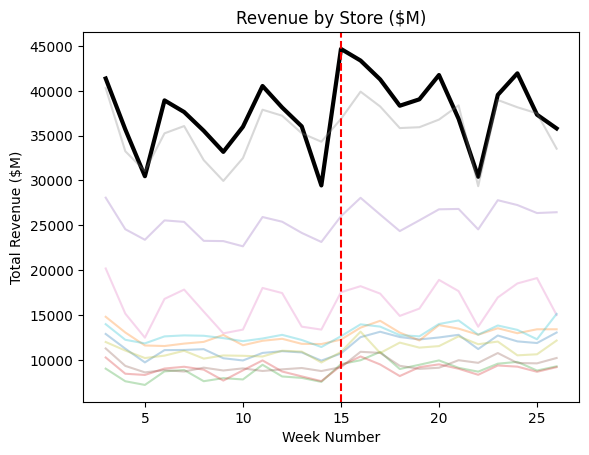

In [6]:
#plotting weekly store revenues without a log transformation
for i in df2['Store'].unique():
  subset = df2[df2['Store'] == i]

  #if i equals the treated unit, highlight it.
  if i == 'Store_1':
    plt.plot(subset['Week'], subset['Revenue'], color='black', linewidth=3, label='Treatment')
  else:
    plt.plot(subset['Week'], subset['Revenue'], alpha=0.3)

#plot titles
plt.axvline(x=15, color='red', linestyle='--')
plt.title('Revenue by Store ($M)')
plt.xlabel('Week Number')
plt.ylabel('Total Revenue ($M)')

Text(0, 0.5, 'Total Revenue (ln)')

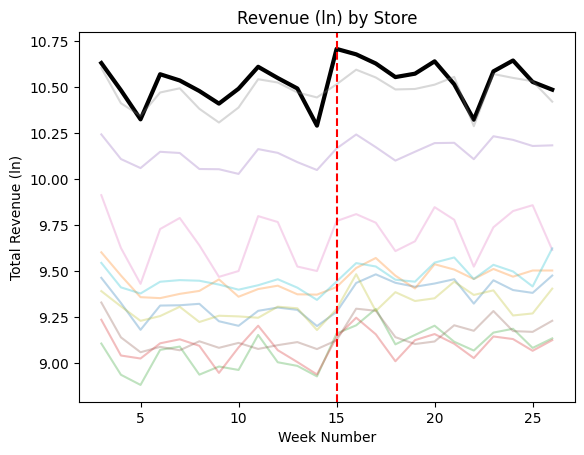

In [7]:
#plotting weekly store revenues with a log transformation
for i in df2['Store'].unique():
  subset = df2[df2['Store'] == i]

  #if i equals the treated unit, highlight it.
  if i == 'Store_1':
    plt.plot(subset['Week'], subset['Revenue_ln'], color='black', linewidth=3, label='Treatment')
  else:
    plt.plot(subset['Week'], subset['Revenue_ln'], alpha=0.3)

#plot titles
plt.axvline(x=15, color='red', linestyle='--')
plt.title('Revenue (ln) by Store')
plt.xlabel('Week Number')
plt.ylabel('Total Revenue (ln)')

##Parallel Trends Assumption:

There are two methods I'm using to test for the parallel trends assumption.

1. Visually
2. "In Time Placebo Test" (Pre-Treatment Period)

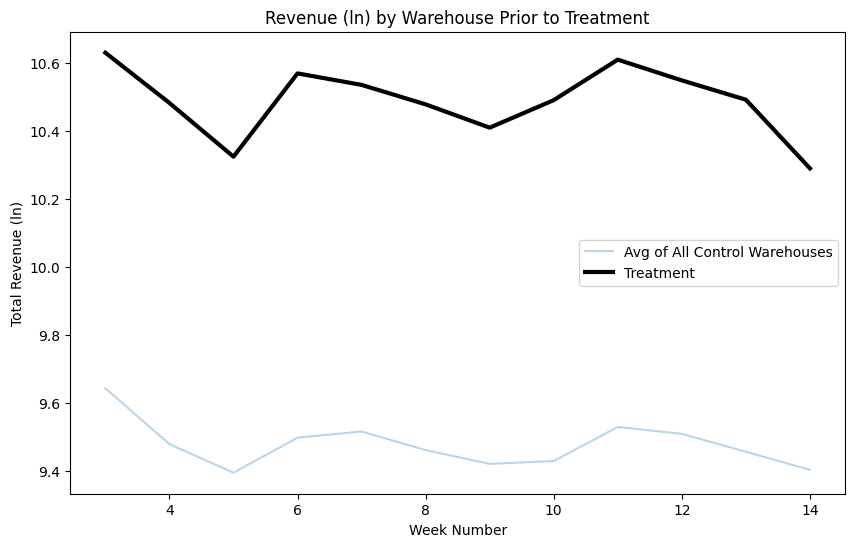

In [ ]:
##visually checking the parallel trends

df2['post_period'] = (df2['Week'] >= 15).astype(int)
df2['treatment'] = (df2['Store'] == 'Store_1').astype(int)

df2['group'] = np.where(df2['Store'] == 'Store_1', 'treatment', 'control')

df2_plot = df2.groupby(['group','Week','post_period'])['Revenue_ln'].mean().reset_index()

df2_plot = df2_plot[df2_plot['Week'] < 15]

plt.figure(figsize=(10,6))

for group in df2_plot['group'].unique():
  subset = df2_plot[df2_plot['group'] == group]

  if group == 'treatment':
    plt.plot(subset['Week'], subset['Revenue_ln'], color='black', linewidth=3, label='Treatment')
  else:
    plt.plot(subset['Week'], subset['Revenue_ln'], alpha=0.3, label='Avg of All Control Warehouses')

plt.title('Revenue (ln) by Warehouse Prior to Treatment')
plt.xlabel('Week Number')
plt.ylabel('Total Revenue (ln)')
plt.legend()
plt.show()

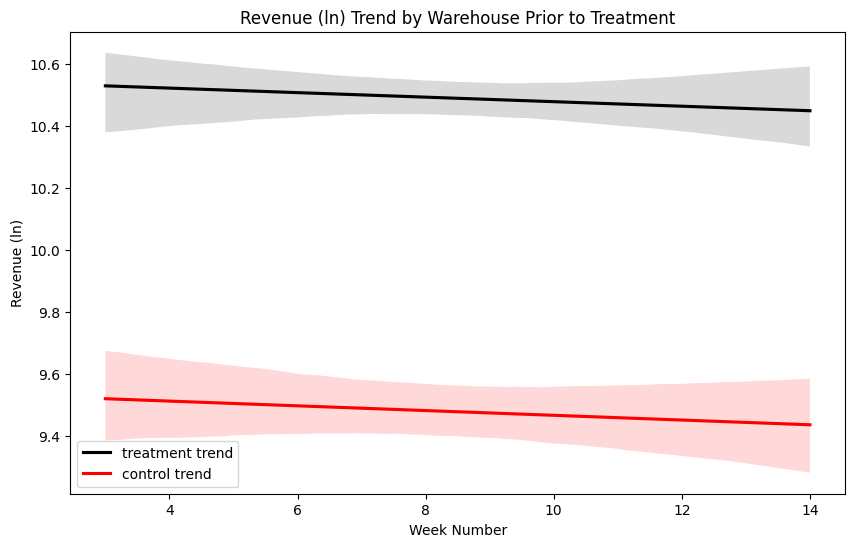

In [14]:
##visually checking the parallel trends using a trend line

df2['post_period'] = (df2['Week'] >= 15).astype(int)
df2['treatment'] = (df2['Store'] == 'Store_1').astype(int)


df2['group'] = np.where(df2['Store'] == 'Store_1', 'treatment', 'control')

df2_plot = df2.groupby(['group','Week','post_period'])['Revenue_ln'].mean().reset_index()

df2_plot = df2_plot[df2_plot['Week'] < 15]

plt.figure(figsize=(10,6))

pre_period = df2[df2['post_period'] == 0]

sns.regplot(data=pre_period[pre_period['treatment'] == 1], x='Week',y='Revenue_ln', scatter=False, color='black',label='treatment trend')

sns.regplot(data=pre_period[pre_period['treatment'] == 0], x='Week',y='Revenue_ln', scatter=False, color='red',label='control trend')


plt.title('Revenue (ln) Trend by Warehouse Prior to Treatment')
plt.xlabel('Week Number')
plt.ylabel('Revenue (ln)')
plt.legend()
plt.show()

For the In Time Placebo testing, I'm taking my 12 weeks of pre-treatment data and dividing it into 6 weeks of placebo pre-treatment data and 6 weeks of placebo-post treatment data.

Then I'm running the 2x2 DiD Regression and checking that the interaction coeffecient is insigificant.

A basic 2x2 difference in differences regression will be:

$$Y_{it} = B_0 + B_1X_{it} + B_2Y_{it} + B3XY_{it} + u_{it}$$

Where X is Group (0/1 for Control/Treatment), Y is Period (0/1 for pre/post treatment), and XY is the interaction.

In [20]:
#preparing data for the in time placebo test
df3 = df2[df2['Week'] < 15].copy()

df3['post_period'] = (df3['Week'] >= 9).astype(int)
df3['treatment'] = (df3['Store'] == 'Store_1').astype(int)

In [21]:
##in time placebo test. Interaction P-value is .237, so the placebo effect is indistiguishable from zero.

import statsmodels.formula.api as smf

model = smf.ols('Revenue_ln ~ treatment + post_period + treatment:post_period', data=df3).fit(
    cov_type = 'cluster', cov_kwds={'groups':df3['Store']})

model.summary()


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Revenue_ln   R-squared:                       0.313
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     24.71
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           0.000135
Time:                        03:07:32   Log-Likelihood:                -76.185
No. Observations:                 132   AIC:                             160.4
Df Residuals:                     128   BIC:                             171.9
Df Model:                           3                                         
Covariance Type:              cluster                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 9.4992      0.148     64.087      0.000       9.209       9.790
treatment                 1.0045      0.148      6.777      0.000       0.714       1.295
post_period              -0.0406      0.009     -4.460      0.000      -0.058      -0.023
treatment:post_period     0.0108      0.009      1.184      0.237      -0.007       0.029
==============================================================================
Omnibus:                       20.251   Durbin-Watson:                   0.279
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               25.157
Skew:                           1.065   Prob(JB):                     3.45e-06
Kurtosis:                       3.197   Cond. No.                         9.19
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

##Running the 2x2 DiD Regression on the full data set.


In [22]:
model = smf.ols('Revenue_ln ~ treatment + post_period + treatment:post_period', data=df2).fit(
    cov_type = 'cluster', cov_kwds={'groups':df2['Store']})

model.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Revenue_ln   R-squared:                       0.322
Model:                            OLS   Adj. R-squared:                  0.315
Method:                 Least Squares   F-statistic:                     24.86
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           0.000132
Time:                        03:07:35   Log-Likelihood:                -148.52
No. Observations:                 264   AIC:                             305.0
Df Residuals:                     260   BIC:                             319.4
Df Model:                           3                                         
Covariance Type:              cluster                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 9.4788      0.148     64.014      0.000       9.189       9.769
treatment                 1.0099      0.148      6.820      0.000       0.720       1.300
post_period               0.0866      0.010      8.593      0.000       0.067       0.106
treatment:post_period    -0.0036      0.010     -0.356      0.722      -0.023       0.016
==============================================================================
Omnibus:                       37.251   Durbin-Watson:                   0.161
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               49.755
Skew:                           1.060   Prob(JB):                     1.57e-11
Kurtosis:                       3.177   Cond. No.                         9.19
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

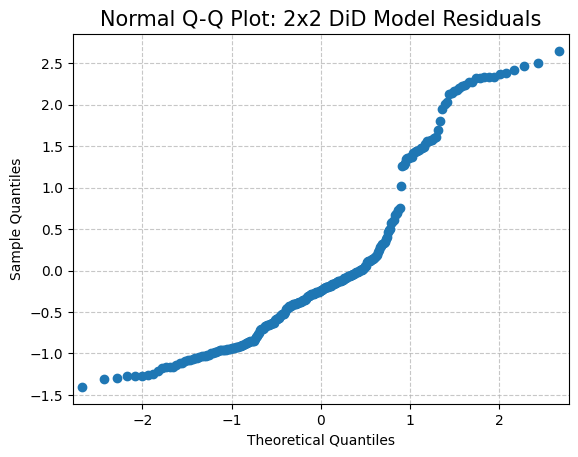

In [23]:
import scipy.stats as stats
import statsmodels.api as sm

residuals = model.resid

fig = sm.qqplot(residuals, fit=True)

plt.title("Normal Q-Q Plot: 2x2 DiD Model Residuals", fontsize=15)
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

  Cloning https://github.com/amazon-science/azcausal.git to /tmp/pip-req-build-d9gnrs74
  Running command git clone --filter=blob:none --quiet https://github.com/amazon-science/azcausal.git /tmp/pip-req-build-d9gnrs74
  Resolved https://github.com/amazon-science/azcausal.git to commit 9f4f78db74c0254f19c94aaa5cdc592f2a049995
  Preparing metadata (setup.py) ... done


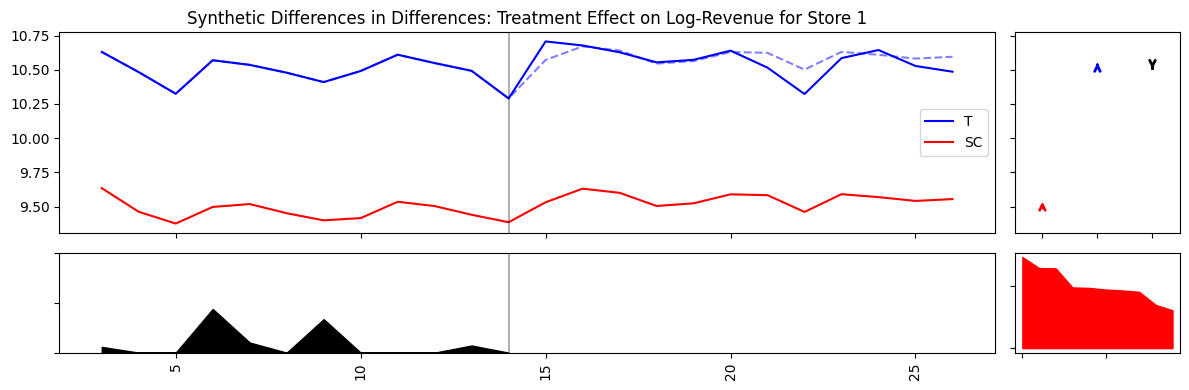

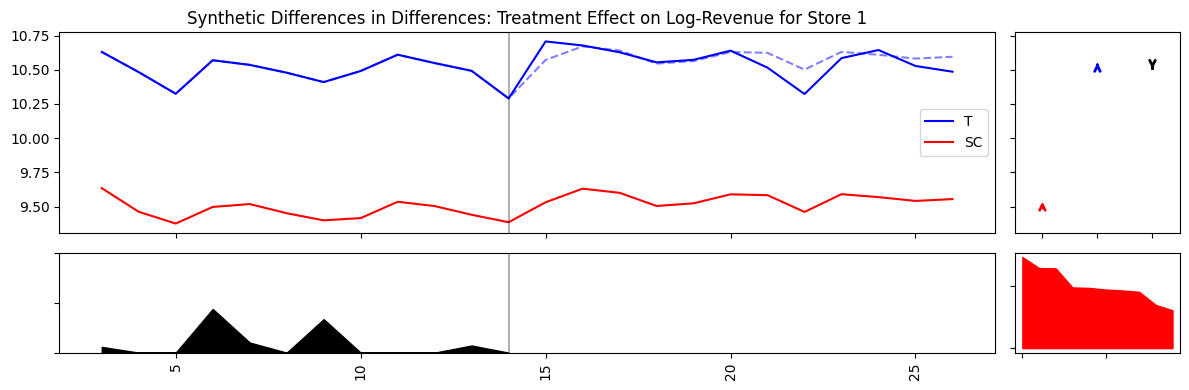

In [25]:
!pip install git+https://github.com/amazon-science/azcausal.git

from azcausal.core.panel import CausalPanel
from azcausal.estimators.panel.sdid import SDID
from azcausal.util import to_panels
from azcausal.core.error import Placebo

df4 = df2.copy()

#adjusting the treatment variable to be compliant with azcausal
df4['treatment'] = ((df4['Store'] == 'Store_1') & (df4['Week'] >= 15)).astype(int)

#loading the data as panel data
data = to_panels(df4, 'Week', 'Store',['Revenue_ln', 'treatment'])

ctypes = dict(outcome='Revenue_ln', time='Week', unit='Store', intervention='treatment')

#initializing the panel
panel = CausalPanel(data).setup(**ctypes)

#initialize an estimator object, synthetic difference in difference (sdid)
estimator = SDID()

#run the estimator
result = estimator.fit(panel)

#run the error validation method
estimator.error(result, Placebo(n_samples=10))

#plot the results
estimator.plot(result, title = "Synthetic Differences in Differences: Treatment Effect on Log-Revenue for Store 1")




In [26]:
#print out the SDiD results
print(result.summary(title="SDiD: Impact of Treatment on Revenue (ln)"))

╭──────────────────────────────────────────────────────────────────────────────╮
|                  SDiD: Impact of Treatment on Revenue (ln)                   |
├──────────────────────────────────────────────────────────────────────────────┤
|                                    Panel                                     |
|  Time Periods: 24 (12/12)                                  total (pre/post)  |
|  Units: 11 (10/1)                                       total (contr/treat)  |
├──────────────────────────────────────────────────────────────────────────────┤
|                                     ATT                                      |
|  Effect (±SE): -0.025336 (±0.052905)                                         |
|  Confidence Interval (95%): [-0.129028 , 0.078356]                    (+/-)  |
|  Observed: 10.57                                                             |
|  Counter Factual: 10.60                                                      |
├───────────────────────────

In [27]:
#viewing the synthetic controls
results = result.info
print(results)

{'did': {'att': np.float64(-0.02533635270765089), 'delta_contr': np.float64(0.08620146503547055), 'delta_treat': np.float64(0.06086511232781966), 'pre_contr': np.float64(9.470534784741442), 'post_contr': 9.556736249776913, 'pre_treat': np.float64(10.510853694593461), 'post_treat': 10.57171880692128}, 'omega': Store_10    0.097081
Store_11    0.060506
Store_2     0.127551
Store_3     0.128059
Store_4     0.090020
Store_5     0.069051
Store_6     0.145631
Store_7     0.096268
Store_8     0.092209
Store_9     0.093625
Name: omega, dtype: float64, 'lambd': 3     0.057496
4     0.000000
5     0.000000
6     0.436142
7     0.100941
8     0.000000
9     0.334235
10    0.000000
11    0.000000
12    0.000000
13    0.071186
14    0.000000
Name: lambd, dtype: float64, 'solvers': {'lambd': {'x': array([0.05749634, 0.        , 0.        , 0.43614153, 0.1009414 ,
       0.        , 0.33423481, 0.        , 0.        , 0.        ,
       0.07118591, 0.        ]), 'f': np.float64(0.00039912346424654575

In [28]:
#store level synthetic controls
unit_weights = result.info.get('omega')
print(unit_weights)

Store_10    0.097081
Store_11    0.060506
Store_2     0.127551
Store_3     0.128059
Store_4     0.090020
Store_5     0.069051
Store_6     0.145631
Store_7     0.096268
Store_8     0.092209
Store_9     0.093625
Name: omega, dtype: float64


In [29]:
#week level synthetic controls
time_weights = result.info.get('lambd')
print(time_weights)

3     0.057496
4     0.000000
5     0.000000
6     0.436142
7     0.100941
8     0.000000
9     0.334235
10    0.000000
11    0.000000
12    0.000000
13    0.071186
14    0.000000
Name: lambd, dtype: float64


##While the primary objective was to test for an increase in revenue, we did not find evidence to support this. Now we're going to redo the experiements on the number of units sold.

In [30]:
#prepare data
df = df[['Store','Week','Units_Sold','Revenue']]
df2 = df.copy()
df2['Units_Sold_ln'] = np.log(df2['Units_Sold'])
df2 = df2.sort_values(['Store','Week'])

Text(0, 0.5, 'Total Units Sold')

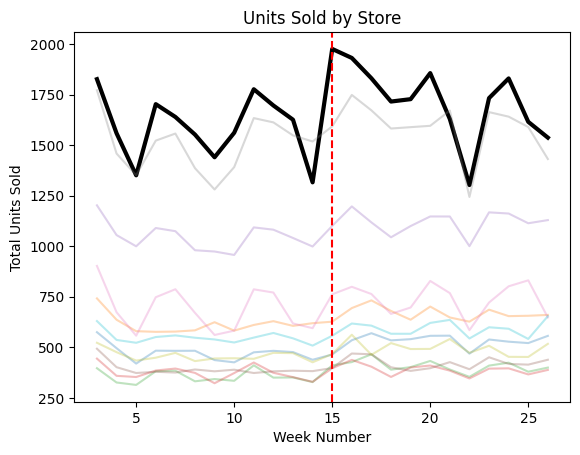

In [31]:
#plotting weekly store unit sales without a log transformation
for i in df2['Store'].unique():
  subset = df2[df2['Store'] == i]

  if i == 'Store_1':
    plt.plot(subset['Week'], subset['Units_Sold'], color='black', linewidth=3, label='Treatment')
  else:
    plt.plot(subset['Week'], subset['Units_Sold'], alpha=0.3)

plt.axvline(x=15, color='red', linestyle='--')
plt.title('Units Sold by Store')
plt.xlabel('Week Number')
plt.ylabel('Total Units Sold')

Text(0, 0.5, 'Total Units Sold (ln)')

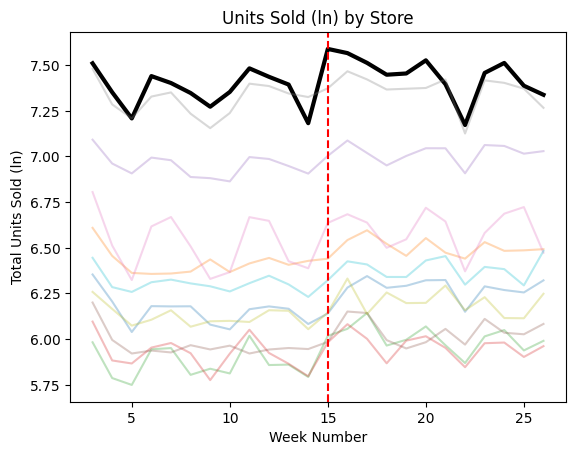

In [32]:
#plotting weekly store units sales with a log transformation
for i in df2['Store'].unique():
  subset = df2[df2['Store'] == i]

  if i == 'Store_1':
    plt.plot(subset['Week'], subset['Units_Sold_ln'], color='black', linewidth=3, label='Treatment')
  else:
    plt.plot(subset['Week'], subset['Units_Sold_ln'], alpha=0.3)

plt.axvline(x=15, color='red', linestyle='--')
plt.title('Units Sold (ln) by Store')
plt.xlabel('Week Number')
plt.ylabel('Total Units Sold (ln)')

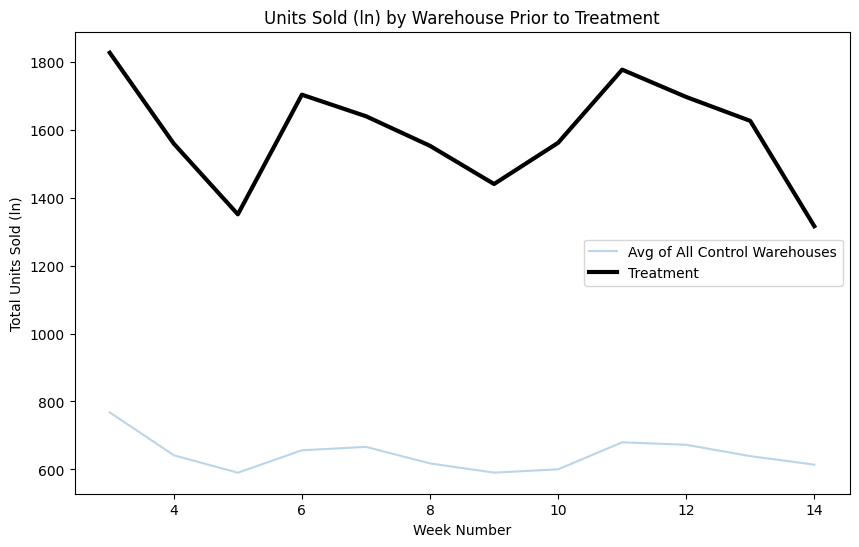

In [33]:
##visually checking the parallel trends

df2['post_period'] = (df2['Week'] >= 15).astype(int)
df2['treatment'] = (df2['Store'] == 'Store_1').astype(int)

df2['group'] = np.where(df2['Store'] == 'Store_1', 'treatment', 'control')

df2_plot = df2.groupby(['group','Week','post_period'])['Units_Sold'].mean().reset_index()

df2_plot = df2_plot[df2_plot['Week'] < 15]

plt.figure(figsize=(10,6))

for group in df2_plot['group'].unique():
  subset = df2_plot[df2_plot['group'] == group]

  if group == 'treatment':
    plt.plot(subset['Week'], subset['Units_Sold'], color='black', linewidth=3, label='Treatment')
  else:
    plt.plot(subset['Week'], subset['Units_Sold'], alpha=0.3, label='Avg of All Control Warehouses')

plt.title('Units Sold (ln) by Warehouse Prior to Treatment')
plt.xlabel('Week Number')
plt.ylabel('Total Units Sold (ln)')
plt.legend()
plt.show()

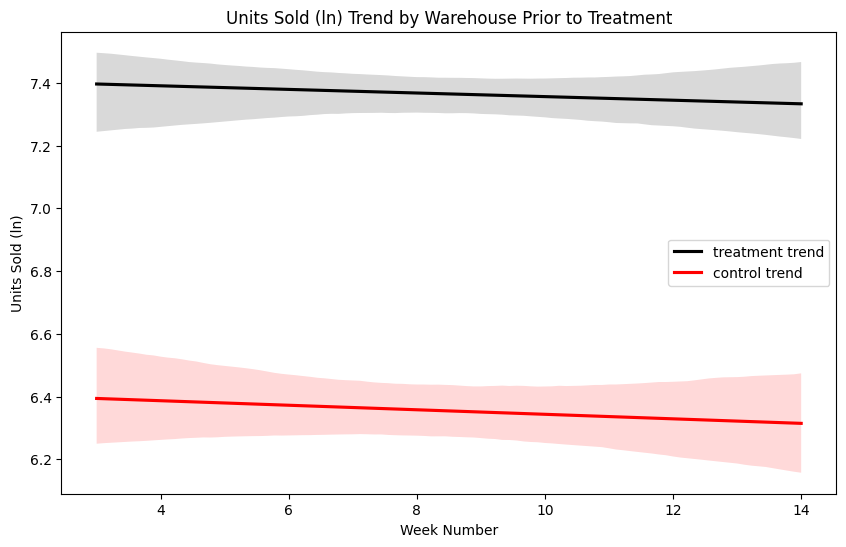

In [34]:
##visually checking the parallel trends using a trend line

df2['post_period'] = (df2['Week'] >= 15).astype(int)
df2['treatment'] = (df2['Store'] == 'Store_1').astype(int)


df2['group'] = np.where(df2['Store'] == 'Store_1', 'treatment', 'control')

df2_plot = df2.groupby(['group','Week','post_period'])['Units_Sold_ln'].mean().reset_index()

df2_plot = df2_plot[df2_plot['Week'] < 15]

plt.figure(figsize=(10,6))

pre_period = df2[df2['post_period'] == 0]

sns.regplot(data=pre_period[pre_period['treatment'] == 1], x='Week',y='Units_Sold_ln', scatter=False, color='black',label='treatment trend')

sns.regplot(data=pre_period[pre_period['treatment'] == 0], x='Week',y='Units_Sold_ln', scatter=False, color='red',label='control trend')


plt.title('Units Sold (ln) Trend by Warehouse Prior to Treatment')
plt.xlabel('Week Number')
plt.ylabel('Units Sold (ln)')
plt.legend()
plt.show()

In [35]:
#preparing data for the in time placebo test
df3 = df2[df2['Week'] < 15].copy()

df3['post_period'] = (df3['Week'] >= 9).astype(int)
df3['treatment'] = (df3['Store'] == 'Store_1').astype(int)

In [36]:
##in time placebo test. Interaction P-value is .106, so the placebo effect is indistiguishable from zero.

import statsmodels.formula.api as smf

model = smf.ols('Units_Sold_ln ~ treatment + post_period + treatment:post_period', data=df3).fit(
    cov_type = 'cluster', cov_kwds={'groups':df3['Store']})

model.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          Units_Sold_ln   R-squared:                       0.313
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     24.64
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           0.000137
Time:                        03:12:41   Log-Likelihood:                -76.404
No. Observations:                 132   AIC:                             160.8
Df Residuals:                     128   BIC:                             172.3
Df Model:                           3                                         
Covariance Type:              cluster                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 6.3739      0.148     42.991      0.000       6.083       6.664
treatment                 1.0026      0.148      6.763      0.000       0.712       1.293
post_period              -0.0395      0.010     -3.939      0.000      -0.059      -0.020
treatment:post_period     0.0162      0.010      1.616      0.106      -0.003       0.036
==============================================================================
Omnibus:                       16.351   Durbin-Watson:                   0.291
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               19.354
Skew:                           0.938   Prob(JB):                     6.27e-05
Kurtosis:                       3.046   Cond. No.                         9.19
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

In [37]:
#Full 2x2 DiD Regression
model = smf.ols('Units_Sold_ln ~ treatment + post_period + treatment:post_period', data=df2).fit(
    cov_type = 'cluster', cov_kwds={'groups':df2['Store']})

model.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          Units_Sold_ln   R-squared:                       0.322
Model:                            OLS   Adj. R-squared:                  0.314
Method:                 Least Squares   F-statistic:                     25.01
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           0.000128
Time:                        03:12:45   Log-Likelihood:                -149.37
No. Observations:                 264   AIC:                             306.7
Df Residuals:                     260   BIC:                             321.1
Df Model:                           3                                         
Covariance Type:              cluster                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 6.3541      0.148     42.890      0.000       6.064       6.645
treatment                 1.0107      0.148      6.822      0.000       0.720       1.301
post_period               0.0812      0.009      9.082      0.000       0.064       0.099
treatment:post_period     0.0003      0.009      0.031      0.975      -0.017       0.018
==============================================================================
Omnibus:                       29.981   Durbin-Watson:                   0.168
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               37.837
Skew:                           0.927   Prob(JB):                     6.08e-09
Kurtosis:                       3.028   Cond. No.                         9.19
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

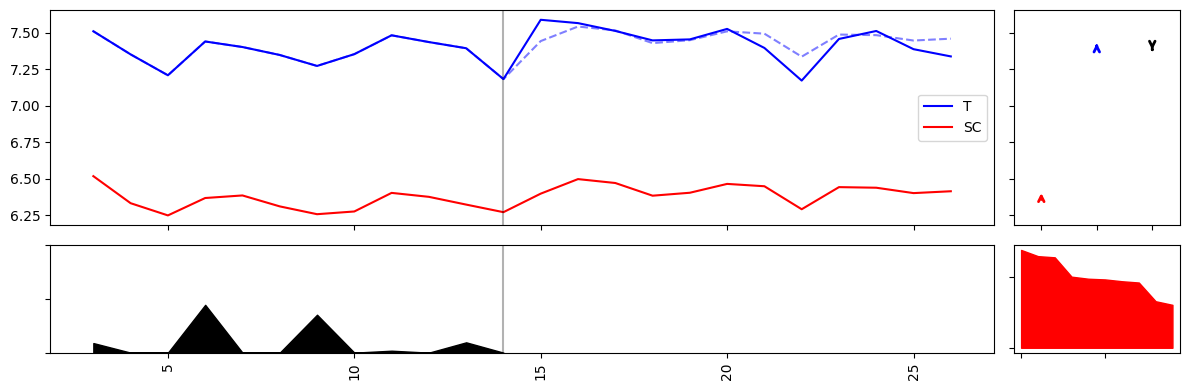

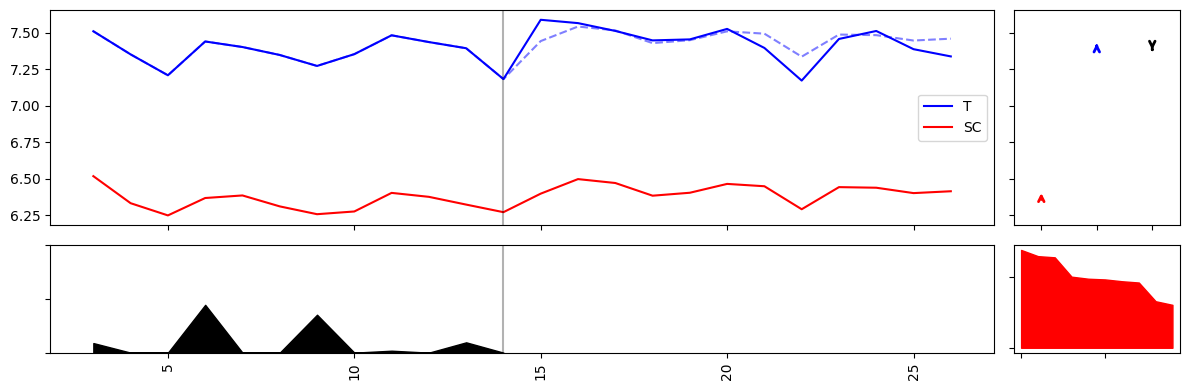

In [38]:
#azcausal SDiD

df4 = df2.copy()
#adjusting the treatment variable to be compliant with azcausal
df4['treatment'] = ((df4['Store'] == 'Store_1') & (df4['Week'] >= 15)).astype(int)

#loading the data as panel data
data = to_panels(df4, 'Week', 'Store',['Units_Sold_ln', 'treatment'])
ctypes = dict(outcome='Units_Sold_ln', time='Week', unit='Store', intervention='treatment')

#initializing the panel
panel = CausalPanel(data).setup(**ctypes)

#run the estimator
result = estimator.fit(panel)

#run the error validation method
estimator.error(result, JackKnife())

#plot the results
estimator.plot(result)


In [ ]:
#print results
print(result.summary(title="SDiD: Impact of Treatment on Units Sold (ln)"))

╭──────────────────────────────────────────────────────────────────────────────╮
|                 SDiD: Impact of Treatment on Units Sold (ln)                 |
├──────────────────────────────────────────────────────────────────────────────┤
|                                    Panel                                     |
|  Time Periods: 24 (12/12)                                  total (pre/post)  |
|  Units: 11 (10/1)                                       total (contr/treat)  |
├──────────────────────────────────────────────────────────────────────────────┤
|                                     ATT                                      |
|  Effect (±SE): -0.019798 (±0.005616)                                         |
|  Confidence Interval (95%): [-0.030805 , -0.008791]                     (-)  |
|  Observed: 7.4463                                                            |
|  Counter Factual: 7.4661                                                     |
├───────────────────────────

The above detects a statistically significant decreased effect on units sold. See paper for additional details.